# CRSP, IBES, Compustat
Bozhi Fu; 25 May 2026

This is a replicating code for linking CRSP, IBES, and Compustat

References

[1] https://wrds-www.wharton.upenn.edu/pages/wrds-research/applications/python-replications/linking-ibes-and-crsp-data-python/

# Section 1 Accessing WRDS

In [12]:
# Accessing WRDS
# Create .pgpass file for remaining logging in

import wrds

db = wrds.Connection()

Enter your WRDS username [fubozhi]: david112
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [113]:
db.connection.rollback()

In [14]:
# print accessible libraries

print(db.list_libraries())

['aha_sample', 'ahasamp', 'audit', 'audit_audit_comp', 'audit_common', 'audit_corp_legal', 'auditsmp', 'auditsmp_all', 'bank', 'bank_all', 'bank_premium_samp', 'banksamp', 'block', 'block_all', 'boardex_trial', 'boardsmp', 'bvd_amadeus_trial', 'bvd_bvdbankf_trial', 'bvd_orbis_trial', 'bvdsamp', 'calcbench_trial', 'calcbnch', 'candid_samp', 'cboe', 'cboe_all', 'cboe_sample', 'cboesamp', 'cddsamp', 'ciq', 'ciq_common', 'ciq_transcripts', 'ciqsamp', 'ciqsamp_capstrct', 'ciqsamp_common', 'ciqsamp_keydev', 'ciqsamp_pplintel', 'ciqsamp_ratings', 'ciqsamp_transactions', 'ciqsamp_transcripts', 'cisdmsmp', 'columnar', 'comp', 'comp_bank_daily', 'comp_execucomp', 'comp_global_daily', 'comp_na_daily_all', 'comp_segments_hist_daily', 'compsamp', 'compsamp_all', 'compsamp_computext', 'compsamp_snapshot', 'compseg', 'contrib', 'contrib_as_filed_financials', 'contrib_bond_firm_link', 'contrib_ceo_turnover', 'contrib_char_returns', 'contrib_corp_fed_litigation', 'contrib_corporate_culture', 'contrib_g

# Section 2 Merging CRSP and IBES through CUSIP/TICKER

Output is a score reflecting the quality of the link

Score = 0 (best link) to Score = 6 (worst link)

More explanation on score system:
- 0: BEST match: using (cusip, cusip dates and company names)       
          or (exchange ticker, company names and 6-digit cusip)     
- 1: Cusips and cusip dates match but company names do not match    
- 2: Cusips and company names match but cusip dates do not match    
- 3: Cusips match but cusip dates and company names do not match    
- 4: tickers and 6-digit cusips match but company names do not match   
- 5: tickers and company names match but 6-digit cusips do not match        
- 6: tickers match but company names and 6-digit cusips do not match

## Step 1 Merging with CUSIP

In [115]:
# 1.1 IBES: Get the list of IBES Tickers for US firms in IBES
_ibes1 = db.raw_sql("""
                      select ticker, cusip, cname, sdates from ibes.id
                      where usfirm=1 and cusip != ''
                      """, date_cols=['sdates'])

In [116]:
print(_ibes1)

      ticker     cusip           cname     sdates
0       0000  87482X10  TALMER BANCORP 2014-02-20
1       0000  87482X10  TALMER BANCORP 2014-03-20
2       0001  26878510       EP ENERGY 2014-02-20
3       0001  26878510       EP ENERGY 2014-03-20
4       0001  26878510    EP ENGR CORP 2014-11-20
...      ...       ...             ...        ...
96084   ZYNX  98986510       ZYNEX MED 2005-07-14
96085   ZYNX  98986510       ZYNEX MED 2006-04-20
96086   ZYNX  98986M10       ZYNEX INC 2008-07-17
96087   ZYNX  98986M10           ZYNEX 2022-08-18
96088   ZYNX  98986M10           ZYNEX 2026-01-15

[96089 rows x 4 columns]


In [117]:
import pandas as pd

# Create first and last 'start dates' for a given cusip
# Use agg min and max to find the first and last date per group
# then rename to fdate and ldate respectively

_ibes1_date = _ibes1.groupby(['ticker','cusip']).sdates.agg(['min', 'max'])\
.reset_index().rename(columns={'min':'fdate', 'max':'ldate'})

# merge fdate ldate back to _ibes1 data
_ibes2 = pd.merge(_ibes1, _ibes1_date,how='left', on =['ticker','cusip'])
_ibes2 = _ibes2.sort_values(by=['ticker','cusip','sdates'])

# keep only the most recent company name
# determined by having sdates = ldate
_ibes2 = _ibes2.loc[_ibes2.sdates == _ibes2.ldate].drop(['sdates'], axis=1)
_ibes2.head(10)

,ticker,cusip,cname,fdate,ldate
1,0000,87482X10,TALMER BANCORP,2014-02-20,2014-03-20
6,0001,26878510,EP ENGR CORP,2014-02-20,2019-10-17
7,0004,02504D10,AMERICAN CAPITAL,2014-02-20,2014-02-20
8,000R,14163310,CARECOM,2014-02-20,2014-02-20
9,000V,15117E10,CELLADON,2014-03-20,2014-03-20
10,000V,28249U10,EIGER,2016-04-14,2016-04-14
12,000V,28249U20,EIGER,2024-01-18,2024-04-18
13,000Y,90400D10,ULTRAGENYX,2014-03-20,2014-03-20
15,000Z,09072V10,BIOCEPT,2014-03-20,2014-05-15
16,000Z,09072V20,BIOCEPT,2016-10-20,2016-10-20


In [121]:
# 1.2 CRSP: Get all permno-ncusip combinations
_crsp1 = db.raw_sql("""
                      select permno, ncusip, comnam, namedt, nameenddt
                      from crsp.stocknames
                      where ncusip != ''
                      """, date_cols=['namedt', 'nameenddt'])

In [123]:
# first namedt
_crsp1_fnamedt = _crsp1.groupby(['permno','ncusip']).namedt.min().reset_index()

# last nameenddt
_crsp1_lnameenddt = _crsp1.groupby(['permno','ncusip']).nameenddt.max().reset_index()

# merge both 
_crsp1_dtrange = pd.merge(_crsp1_fnamedt, _crsp1_lnameenddt, \
                          on = ['permno','ncusip'], how='inner')

# replace namedt and nameenddt with the version from the dtrange
_crsp1 = _crsp1.drop(['namedt'],axis=1).rename(columns={'nameenddt':'enddt'})
_crsp2 = pd.merge(_crsp1, _crsp1_dtrange, on =['permno','ncusip'], how='inner')

# keep only most recent company name
_crsp2 = _crsp2.loc[_crsp2.enddt ==_crsp2.nameenddt].drop(['enddt'], axis=1)
_crsp2.head(10)

,permno,ncusip,comnam,namedt,nameenddt
0,10000,68391610,OPTIMUM MANUFACTURING INC,1986-01-07,1987-06-11
1,10001,39040610,GREAT FALLS GAS CO,1986-01-09,1993-11-21
2,10001,29274A10,ENERGY WEST INC,1993-11-22,2008-02-04
3,10001,29274A20,ENERGY WEST INC,2008-02-05,2009-08-03
5,10001,29269V10,ENERGY INC,2009-08-04,2010-07-08
6,10001,36720410,GAS NATURAL INC,2010-07-09,2017-08-03
7,10002,60740110,MOBILE NATIONAL CORP,1986-01-10,1993-09-29
9,10002,83623410,SOUTH ALABAMA BANCORPORATION INC,1993-09-30,2002-05-14
10,10002,05978R10,BANCTRUST FINANCIAL GROUP INC,2002-05-15,2013-02-15
12,10003,39031810,GREAT COUNTRY BK ASONIA CT,1986-01-14,1995-12-15


In [125]:
# 1.3 Create CUSIP Link Table

# Link by full cusip, company names and dates
_link1_1 = pd.merge(_ibes2, _crsp2, how='inner', left_on='cusip', right_on='ncusip').sort_values(['ticker','permno','ldate'])

In [131]:
# Keep link with most recent company name
_link1_1_tmp = _link1_1.groupby(['ticker','permno']).ldate.max().reset_index()
_link1_2 = pd.merge(_link1_1, _link1_1_tmp, how='inner', on =['ticker', 'permno', 'ldate'])

In [133]:
from fuzzywuzzy import fuzz

# Calculate name matching ratio using FuzzyWuzzy

# Note: fuzz ratio = 100 -> match perfectly
#       fuzz ratio = 0   -> do not match at all

# Comment: token_set_ratio is more flexible in matching the strings:
# fuzz.token_set_ratio('AMAZON.COM INC',  'AMAZON COM INC')
# returns value of 100

# fuzz.ratio('AMAZON.COM INC',  'AMAZON COM INC')
# returns value of 93

_link1_2['name_ratio'] = _link1_2.apply(lambda x: fuzz.token_set_ratio(x.comnam, x.cname), axis=1)

# Note on parameters:
# The following parameters are chosen to mimic the SAS macro %iclink
# In %iclink, name_dist < 30 is assigned score = 0
# where name_dist=30 is roughly 90% percentile in total distribution
# and higher name_dist means more different names.
# In name_ratio, I mimic this by choosing 10% percentile as cutoff to assign
# score = 0

# 10% percentile of the company name distance
name_ratio_p10 = _link1_2.name_ratio.quantile(0.10)
name_ratio_p10

67.0

In [135]:
# Function to assign score for companies matched by:
# full cusip and passing name_ratio
# or meeting date range requirement

def score1(row):
    if (row['fdate']<=row['nameenddt']) & (row['ldate']>=row['namedt']) & (row['name_ratio'] >= name_ratio_p10):
        score = 0
    elif (row['fdate']<=row['nameenddt']) & (row['ldate']>=row['namedt']):
        score = 1
    elif row['name_ratio'] >= name_ratio_p10:
        score = 2
    else:
        score = 3
    return score

# assign size portfolio
_link1_2['score']=_link1_2.apply(score1, axis=1)
_link1_2 = _link1_2[['ticker','permno','cname','comnam','name_ratio','score']]
_link1_2 = _link1_2.drop_duplicates()

In [137]:
_link1_2.groupby(['score']).score.count()

score
0    18979
1     1911
2      710
3       86
Name: score, dtype: int64

## Step 2 Merging with TICKER

In [139]:
# Find links for the remaining unmatched cases using Exchange Ticker 

# Identify remaining unmatched cases 
_nomatch1 = pd.merge(_ibes2[['ticker']], _link1_2[['permno','ticker']], on='ticker', how='left')
_nomatch1 = _nomatch1.loc[_nomatch1.permno.isnull()].drop(['permno'], axis=1).drop_duplicates()
_nomatch1

,ticker
33,002B
74,006E
105,008Y
112,00A8
117,00AP
...,...
42514,ZNTH
42539,ZORK
42563,ZTCO
42573,ZU03


In [141]:
# Add IBES identifying information

ibesid = db.raw_sql(""" select ticker, cname, oftic, sdates, cusip from ibes.id """, date_cols=['sdates'])
ibesid = ibesid.loc[ibesid.oftic.notna()]

_nomatch2 = pd.merge(_nomatch1, ibesid, how='inner', on=['ticker'])
_nomatch2.shape

(17504, 5)

In [143]:
# Create first and last 'start dates' for Exchange Tickers
# Label date range variables and keep only most recent company name

_nomatch3 = _nomatch2.groupby(['ticker', 'oftic']).sdates.agg(['min', 'max']).reset_index().rename(columns={'min':'fdate', 'max':'ldate'})

_nomatch3 = pd.merge(_nomatch2, _nomatch3, how='left', on=['ticker','oftic'])

_nomatch3 = _nomatch3.loc[_nomatch3.sdates == _nomatch3.ldate]
_nomatch3.shape

(8797, 7)

In [145]:
# Get entire list of CRSP stocks with Exchange Ticker information

_crsp_n1 = db.raw_sql(""" select ticker, comnam, permno, ncusip, namedt, nameenddt
                            from crsp.stocknames """, date_cols=['namedt', 'nameenddt'])

_crsp_n1 = _crsp_n1.loc[_crsp_n1.ticker.notna()].sort_values(by=['permno','ticker','namedt'])

In [147]:
# Arrange effective dates for link by Exchange Ticker

_crsp_n1_namedt = _crsp_n1.groupby(['permno','ticker']).namedt.min().reset_index().rename(columns={'min':'namedt'})
_crsp_n1_nameenddt = _crsp_n1.groupby(['permno','ticker']).nameenddt.max().reset_index().rename(columns={'max':'nameenddt'})

_crsp_n1_dt = pd.merge(_crsp_n1_namedt, _crsp_n1_nameenddt, how = 'inner', on=['permno','ticker'])

_crsp_n1 = _crsp_n1.rename(columns={'namedt': 'namedt_ind', 'nameenddt':'nameenddt_ind'})

In [149]:
_crsp_n2 = pd.merge(_crsp_n1, _crsp_n1_dt, how ='left', on = ['permno','ticker'])

_crsp_n2 = _crsp_n2.rename(columns={'ticker':'crsp_ticker'})
_crsp_n2 = _crsp_n2.loc[_crsp_n2.nameenddt_ind == _crsp_n2.nameenddt].drop(['namedt_ind', 'nameenddt_ind'], axis=1)

In [151]:
# Merge remaining unmatched cases using Exchange Ticker 
# Note: Use ticker date ranges as exchange tickers are reused overtime

_link2_1 = pd.merge(_nomatch3, _crsp_n2, how='inner', left_on=['oftic'], right_on=['crsp_ticker'])
_link2_1 = _link2_1.loc[(_link2_1.ldate>=_link2_1.namedt) & (_link2_1.fdate<=_link2_1.nameenddt)]

In [153]:
# Score using company name using 6-digit CUSIP and company name spelling distance
_link2_1['name_ratio'] = _link2_1.apply(lambda x: fuzz.token_set_ratio(x.comnam, x.cname), axis=1)

_link2_2 = _link2_1
_link2_2['cusip6'] = _link2_2.apply(lambda x: x.cusip[:6], axis=1)
_link2_2['ncusip6'] = _link2_2.apply(lambda x: x.ncusip[:6], axis=1)

In [155]:
# Score using company name using 6-digit CUSIP and company name spelling distance

def score2(row):
    if (row['cusip6']==row['ncusip6']) & (row['name_ratio'] >= name_ratio_p10):
        score = 0
    elif (row['cusip6']==row['ncusip6']):
        score = 4
    elif row['name_ratio'] >= name_ratio_p10:
        score = 5
    else:
        score = 6
    return score

# assign size portfolio
_link2_2['score']=_link2_2.apply(score2, axis=1)

In [157]:
# Some companies may have more than one TICKER-PERMNO link
# so re-sort and keep the case (PERMNO & Company name from CRSP)
# that gives the lowest score for each IBES TICKER 

_link2_2 = _link2_2[['ticker','permno','cname','comnam', 'name_ratio', 'score']].sort_values(by=['ticker','score'])
_link2_2_score = _link2_2.groupby(['ticker']).score.min().reset_index()

_link2_3 = pd.merge(_link2_2, _link2_2_score, how='inner', on=['ticker', 'score'])
_link2_3 = _link2_3[['ticker','permno','cname','comnam','score']].drop_duplicates()

In [159]:
import pandas as pd
import numpy as np

# Finalize links and scores
iclink = pd.concat([_link1_2, _link2_3])

In [161]:
from pathlib import Path

# Storing iclink for other program usage
iclink.to_csv(Path.home().joinpath('iclink.csv'))

In [177]:
# Storing iclink locally
local_path = "/Users/fubozhi/FIN-DATA/linktable/iclink.csv"
iclink.to_csv(local_path, index=False)

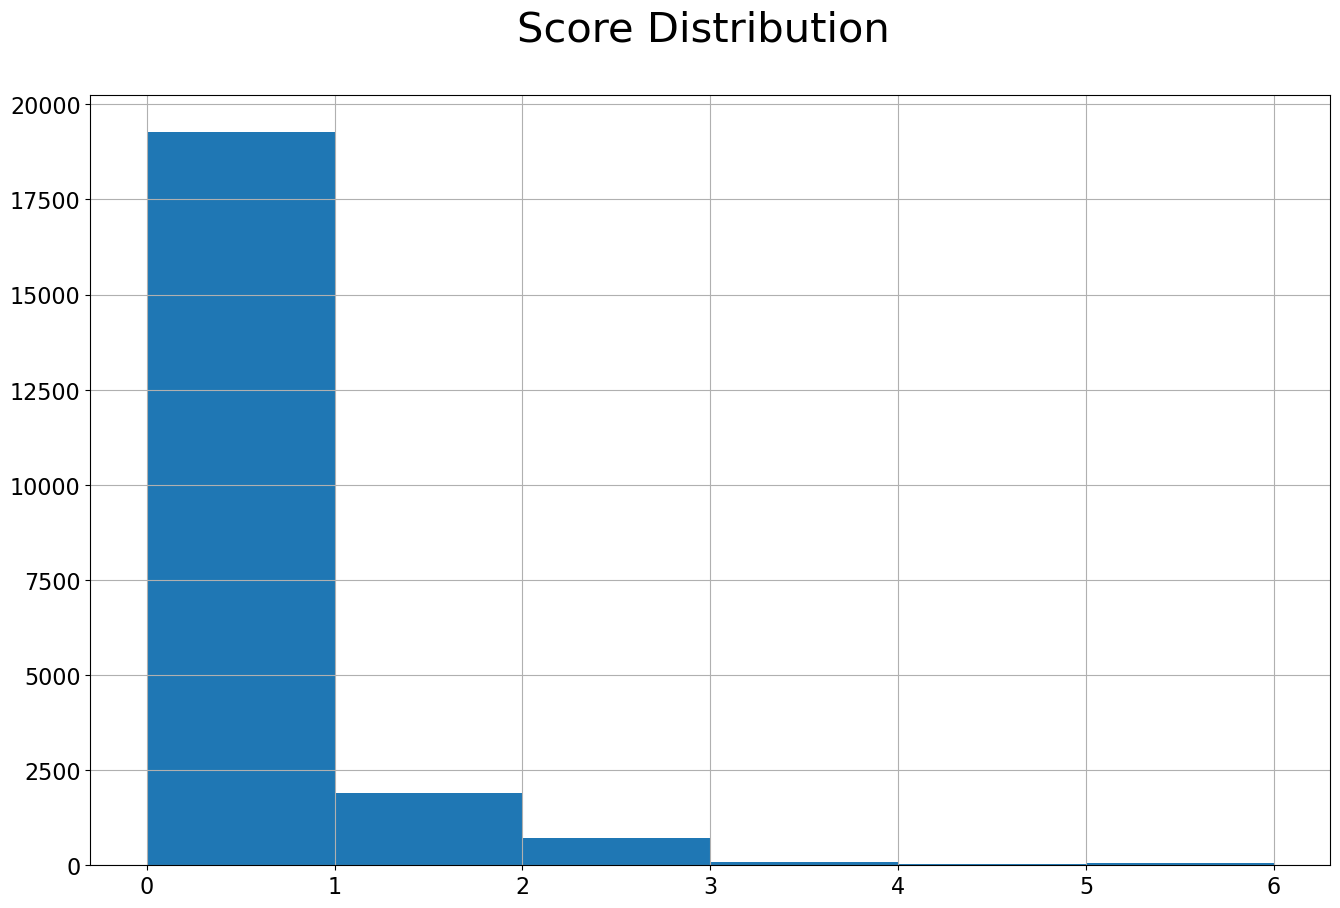

In [163]:
# Plotting summary statistics output:

import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,10))
plt.title('Score Distribution \n', fontsize=30)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
iclink.score.hist(bins=6)

plt.savefig(Path.home().joinpath('iclink_score.png'))
plt.show()

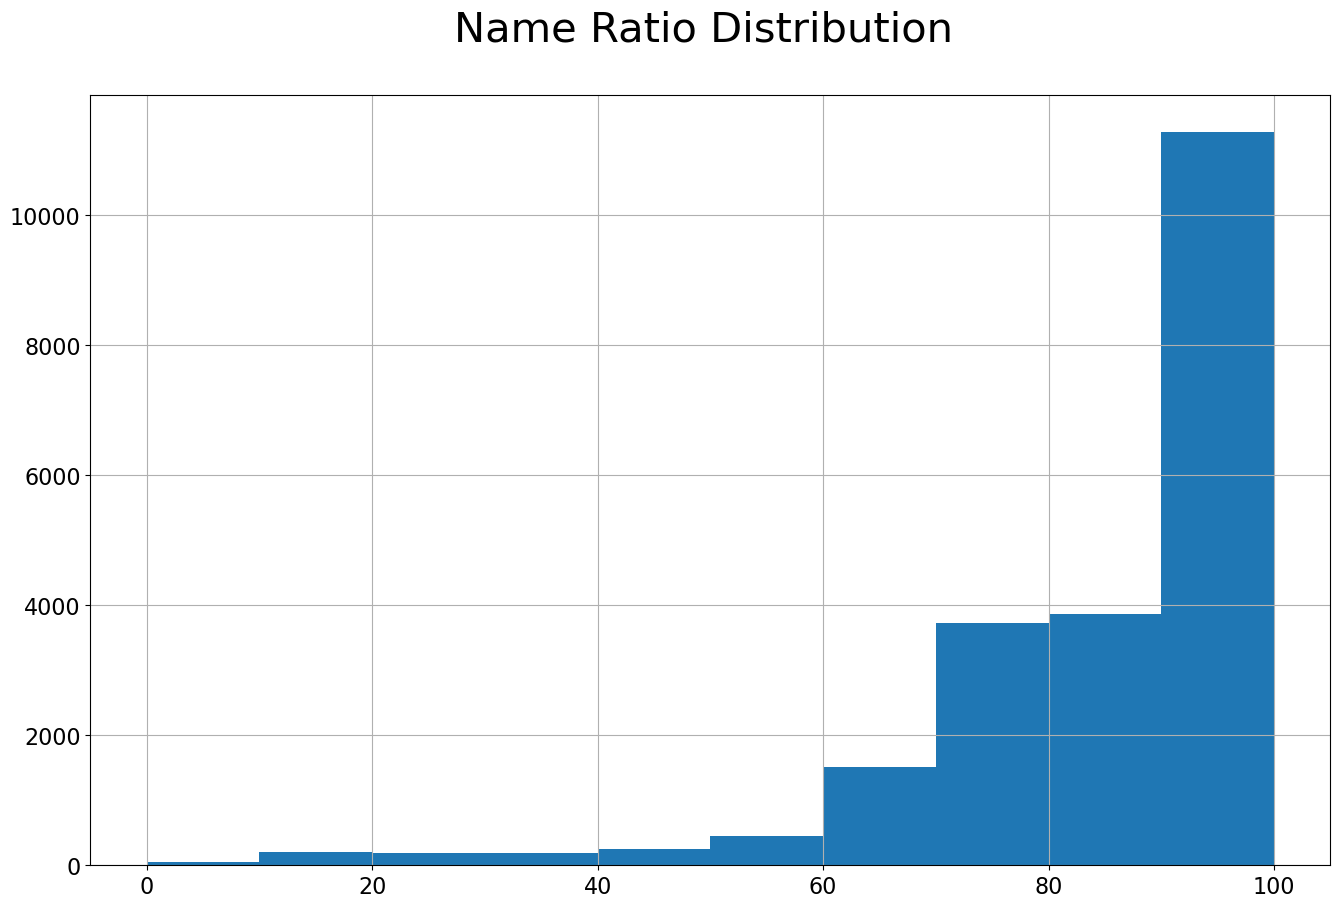

In [165]:
%matplotlib inline

plt.figure(figsize=(16,10))
plt.title('Name Ratio Distribution \n', fontsize=30)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
iclink.name_ratio.hist()

plt.savefig(Path.home().joinpath('iclink_name_ratio.png'))
plt.show()

In [167]:
sample_out = iclink.loc[(iclink.permno==58827) | (iclink.permno==11081) | \
           (iclink.permno==75161) | (iclink.permno==12490) | \
           (iclink.permno==10107)]

sample_out[['permno', 'name_ratio']] = sample_out[['permno', 'name_ratio']].astype(int)
sample_out = sample_out[['ticker', 'permno','cname','comnam', 'name_ratio', 'score']]

sample_out

/var/folders/js/v4b7674569xb00v24gf98wrh0000gn/T/ipykernel_68858/685786167.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_out[['permno', 'name_ratio']] = sample_out[['permno', 'name_ratio']].astype(int)


,ticker,permno,cname,comnam,name_ratio,score
2878,BAC,58827,BANKAMERICA CA,BANKAMERICA CORP,88,0
6116,DELL,11081,DELL INC,DELL INC,100,0
7795,FFS,75161,1ST FED BCP DEL,FIRST FEDERAL BANCORP DE,51,3
10190,IBM,12490,IBM,INTERNATIONAL BUSINESS MACHS COR,11,1
13279,MSFT,10107,MICROSOFT,MICROSOFT CORP,100,0


# Section 3 Merging Compustat and CRSP+IBES through gvkey

In [187]:
ccm = db.raw_sql("""
    select gvkey, lpermno as permno, linktype, linkprim,
           linkdt, linkenddt
    from crsp.ccmxpf_lnkhist
    where linktype in ('LC', 'LU')
      and linkprim in ('C', 'P')
""", date_cols=["linkdt", "linkenddt"])

# if linkenddt is missing then set to today date
ccm['linkenddt']=ccm['linkenddt'].fillna(pd.to_datetime('today'))
ccm

,gvkey,permno,linktype,linkprim,linkdt,linkenddt
0,001000,25881.0,LU,P,1970-11-13,1978-06-30 00:00:00.000000
1,001001,10015.0,LU,P,1983-09-20,1986-07-31 00:00:00.000000
2,001002,10023.0,LC,C,1972-12-14,1973-06-05 00:00:00.000000
3,001003,10031.0,LU,C,1983-12-07,1989-08-16 00:00:00.000000
4,001004,54594.0,LU,P,1972-04-24,2026-05-25 14:55:53.090105
...,...,...,...,...,...,...
33319,356257,27397.0,LC,P,2025-09-26,2026-05-25 14:55:53.090105
33320,356289,25036.0,LC,P,2024-04-08,2026-05-25 14:55:53.090105
33321,356859,26277.0,LC,P,2025-02-18,2026-05-25 14:55:53.090105
33322,366911,26806.0,LC,P,2025-06-23,2026-05-25 14:55:53.090105


In [197]:
icclink = pd.merge(iclink, ccm, how='inner', on=['permno'])
icclink.drop(['linktype', 'linkprim'], axis=1, inplace=True)
icclink.rename(columns={
    "linkdt": "gvkeylinkdt",
    "linkenddt": "gvkeylinkenddt",
    "score": "icscore"
}, inplace=True)
icclink

,ticker,permno,cname,comnam,name_ratio,icscore,gvkey,gvkeylinkdt,gvkeylinkenddt
0,0000,14471,TALMER BANCORP,TALMER BANCORP INC,100.0,0,192458,2014-02-12,2016-09-30
1,0001,14392,EP ENGR CORP,E P ENERGY CORP,67.0,0,018660,2014-01-17,2019-04-30
2,0004,14418,AMERICAN CAPITAL,AMERICAN CAPITAL SR FLOATING LTD,100.0,0,019545,2014-01-16,2018-09-28
3,000R,14378,CARECOM,CARE COM INC,74.0,0,019352,2014-01-24,2020-02-28
4,000V,14423,EIGER,EIGER BIOPHARMACEUTICALS INC,100.0,0,018929,2014-01-30,2016-03-22
...,...,...,...,...,...,...,...,...,...
24296,WTC2,89693,WESTERN SILVER,WESTERN SILVER CORP,NaN,0,151077,2003-02-05,2006-05-31
24297,XGXG,12599,EXTORRE GOLD,EXTORRE GOLD MINES LTD,NaN,0,184511,2011-03-14,2012-08-31
24298,XRA,91573,EXETER RESOURCE,EXETER RESOURCES CORP,NaN,0,166220,2006-11-09,2017-08-31
24299,YM2,90397,YM BIOSCIENCES,Y M BIOSCIENCES INC,NaN,0,149065,2004-10-01,2013-02-28


In [243]:
# store
local_path = "/Users/fubozhi/FIN-DATA/linktable/icclink.csv"
icclink.to_csv(local_path, index=False)

In [235]:
### example

comp = db.raw_sql("""
                    select gvkey, datadate
                    from comp.funda
                    where indfmt = 'INDL'          -- industrial format
                    and datafmt = 'STD'          -- standard data format
                    and popsrc = 'D'             -- domestic firms
                    and consol = 'C'             -- consolidated statements
                    and datadate between date '1960-01-01' and date '2024-12-31'
                    """, date_cols=['datadate'])

comp['year']=comp['datadate'].dt.year

In [236]:
# keep only the last available information for each firm-year group
comp = (
    comp
    .assign(year=lambda x: x["datadate"].dt.year)
    .sort_values("datadate")
    .groupby(["gvkey", "year"])
    .tail(1)
    .reset_index(drop=True)
)

In [237]:
# number of years in Compustat
comp=comp.sort_values(by=['gvkey','datadate'])
comp['count']=comp.groupby(['gvkey']).cumcount()
comp

,gvkey,datadate,year,count
3712,001000,1961-12-31,1961,0
6124,001000,1962-12-31,1962,1
8956,001000,1963-12-31,1963,2
12362,001000,1964-12-31,1964,3
14408,001000,1965-12-31,1965,4
...,...,...,...,...
565139,366911,2024-12-31,2024,2
552599,369350,2023-12-31,2023,0
565256,369350,2024-12-31,2024,1
561136,370994,2023-12-31,2023,0


In [241]:
from pandas.tseries.offsets import YearEnd, MonthEnd

comp["yearend"] = comp["datadate"] + YearEnd(0)
comp["jdate"] = comp["yearend"] + MonthEnd(6)

comp_temp = comp.merge(
    icclink,
    on="gvkey",
    how="left"
)

comp_linked = comp_temp[
    (comp_temp["jdate"] >= comp_temp["gvkeylinkdt"]) &
    (comp_temp["jdate"] <= comp_temp["gvkeylinkenddt"]) &
    (comp_temp["icscore"] == 0)
]

comp_linked.drop (['name_ratio', 'icscore','gvkeylinkdt', 'gvkeylinkenddt'], axis=1, inplace=True)
comp_linked  

/var/folders/js/v4b7674569xb00v24gf98wrh0000gn/T/ipykernel_68858/2170082078.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comp_linked.drop (['name_ratio', 'icscore','gvkeylinkdt', 'gvkeylinkenddt'], axis=1, inplace=True)


,gvkey,datadate,year,count,yearend,jdate,ticker,permno,cname,comnam
22,001001,1983-12-31,1983,5,1983-12-31,1984-06-30,AMFD,10015,A&M FOOD SERVICE,A & M FOOD SERVICES INC
23,001001,1984-12-31,1984,6,1984-12-31,1985-06-30,AMFD,10015,A&M FOOD SERVICE,A & M FOOD SERVICES INC
24,001001,1985-12-31,1985,7,1985-12-31,1986-06-30,AMFD,10015,A&M FOOD SERVICE,A & M FOOD SERVICES INC
41,001003,1983-12-31,1983,3,1983-12-31,1984-06-30,ANTQ,10031,AA IMPORTING INC,A A IMPORTING INC
42,001003,1984-12-31,1984,4,1984-12-31,1985-06-30,ANTQ,10031,AA IMPORTING INC,A A IMPORTING INC
...,...,...,...,...,...,...,...,...,...,...
666766,353444,2022-12-31,2022,1,2022-12-31,2023-06-30,HLN,23209,HALEON,HALEON PLC
666767,353444,2023-12-31,2023,2,2023-12-31,2024-06-30,HLN,23209,HALEON,HALEON PLC
666768,353444,2024-12-31,2024,3,2024-12-31,2025-06-30,HLN,23209,HALEON,HALEON PLC
666781,355398,2023-12-31,2023,2,2023-12-31,2024-06-30,051B,25134,SUPER HI INTL,SUPER HI INTERNATIONAL HLDG LTD
